 # 02 - EDA on shortlisted cities

 Per city: time coverage, data quality, courier structure, demand structure,

 baseline preview and static-allocation overload preview.

 Complexity: O(N) time and memory per city, plus O(R*T) for the region-day grid.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "delivery"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

CITY_CODES = ["yt", "cq", "hz"]
TEST_DAYS = 30
# ds encodes MMDD; the real year is unknown, so a dummy year is used for the calendar only
ORIGIN = pd.Timestamp("2001-05-01")
NUM_DAYS = (pd.Timestamp("2001-10-31") - ORIGIN).days + 1  # 184

TIME_COLS = ["accept_time", "accept_gps_time", "delivery_time", "delivery_gps_time"]
GPS_COLS = ["lng", "lat", "accept_gps_lng", "accept_gps_lat",
            "delivery_gps_lng", "delivery_gps_lat"]


def loadCity(cityCode):
    df = pd.read_parquet(RAW_DIR / f"delivery_{cityCode}.parquet")
    df["date"] = pd.to_datetime(
        "2001" + df["ds"].astype(str).str.zfill(4), format="%Y%m%d")
    df["dayOffset"] = (df["date"] - ORIGIN).dt.days
    for col in TIME_COLS:
        df[col + "Dt"] = pd.to_datetime(
            "2001-" + df[col], format="%Y-%m-%d %H:%M:%S", errors="coerce")
    return df


def toMMDD(dayOffset):
    return (ORIGIN + pd.Timedelta(days=int(dayOffset))).strftime("%m-%d")



 ## Block 1 - time coverage and weekly pattern

In [2]:
def reportCoverage(df):
    # NaN marks a day with no data at all
    dailyOrders = df.groupby("dayOffset").size().reindex(range(NUM_DAYS))
    filled = dailyOrders.dropna()
    print("days present:", len(filled), "| missing:", int(dailyOrders.isna().sum()))
    print("lag-7 autocorr:", round(float(dailyOrders.autocorr(lag=7)), 3))
    weekRatio = (filled.groupby(filled.index % 7).mean() / filled.mean()).round(2)
    print("ratio to mean by weekPhase (dayOffset % 7):", weekRatio.to_dict())
    print("top-5 days:", {toMMDD(d): int(v) for d, v in filled.nlargest(5).items()})
    print("low-5 days:", {toMMDD(d): int(v) for d, v in filled.nsmallest(5).items()})
    return dailyOrders



 ## Block 2 - data quality and time-field semantics

In [3]:
def reportQuality(df):
    quality = pd.DataFrame({"nanShare": df[GPS_COLS].isna().mean(),
                            "zeroShare": (df[GPS_COLS] == 0).mean()})
    print(quality.round(4).to_string())
    parsed = df[[c + "Dt" for c in TIME_COLS]].isna().mean().round(4)
    print("unparsed time share:", parsed.to_dict())

    qs = [0.5, 0.9, 0.99]
    durationMin = (df["delivery_timeDt"] - df["accept_timeDt"]).dt.total_seconds() / 60
    print("delivery - accept minutes q50/q90/q99:", durationMin.quantile(qs).round(1).tolist())
    print("negative duration share:", round(float((durationMin < 0).mean()), 4))
    gpsLagMin = (df["accept_gps_timeDt"] - df["accept_timeDt"]).abs().dt.total_seconds() / 60
    print("|accept_gps_time - accept_time| minutes q50/q90/q99:",
          gpsLagMin.quantile(qs).round(1).tolist())
    deliveryMMDD = df["delivery_timeDt"].dt.month * 100 + df["delivery_timeDt"].dt.day
    print("share delivery date == ds:", round(float((deliveryMMDD == df["ds"]).mean()), 4))
    hourShare = df["delivery_timeDt"].dt.hour.value_counts(normalize=True).sort_index()
    print("delivery hour share:", hourShare.round(3).to_dict())

    # Rough region extent in km (approximate degree-to-km constants)
    box = df.groupby("region_id").agg(lngMin=("lng", "min"), lngMax=("lng", "max"),
                                      latMin=("lat", "min"), latMax=("lat", "max"))
    midLat = np.deg2rad((box["latMin"] + box["latMax"]) / 2)
    widthKm = (box["lngMax"] - box["lngMin"]) * 111.32 * np.cos(midLat)
    heightKm = (box["latMax"] - box["latMin"]) * 110.57
    diagKm = np.sqrt(widthKm ** 2 + heightKm ** 2)
    print("region bbox diagonal km median/p90:", round(float(diagKm.median()), 1),
          round(float(diagKm.quantile(0.9)), 1))



 ## Block 3 - courier structure, K and Q

In [4]:
def reportCouriers(df):
    courierDay = df.groupby(["dayOffset", "courier_id"]).agg(
        orders=("order_id", "size"), regions=("region_id", "nunique"))
    couriersPerDay = df.groupby("dayOffset")["courier_id"].nunique()
    activeDays = df.groupby("courier_id")["dayOffset"].nunique()
    qCap = float(courierDay["orders"].quantile(0.9))
    sameRegionShare = float((courierDay["regions"] == 1).mean())
    print("courier-days within a single region:", round(sameRegionShare, 3))
    print("couriers/day mean/std/min/max:", round(float(couriersPerDay.mean()), 1),
          round(float(couriersPerDay.std()), 1), int(couriersPerDay.min()),
          int(couriersPerDay.max()))
    print("active days per courier q25/q50/q75:", activeDays.quantile([0.25, 0.5, 0.75]).tolist())
    print("Q (p90 orders per courier-day):", qCap)
    return couriersPerDay, qCap, sameRegionShare



 ## Block 4 - demand structure, baselines, static-allocation overload

In [5]:
def buildGrid(df):
    grid = df.groupby(["region_id", "dayOffset"]).size().unstack(fill_value=0)
    return grid.reindex(columns=range(NUM_DAYS), fill_value=0)


def reportDemand(grid, couriersPerDay, qCap):
    regionMean = grid.mean(axis=1)
    cvRegions = float(regionMean.std() / regionMean.mean())
    top5Share = float(regionMean.nlargest(5).sum() / regionMean.sum())
    dayCv = float((grid.std(axis=1) / grid.mean(axis=1)).median())
    print("regions:", len(grid), "| cv of region means:", round(cvRegions, 3),
          "| top-5 region share:", round(top5Share, 3))
    print("median day-to-day cv per region:", round(dayCv, 3))

    trainEnd = NUM_DAYS - TEST_DAYS
    train = grid.iloc[:, :trainEnd]
    actual = grid.iloc[:, trainEnd:].to_numpy()
    weekPhase = np.arange(NUM_DAYS) % 7
    predMean = np.repeat(train.mean(axis=1).to_numpy()[:, None], TEST_DAYS, axis=1)
    predPhase = np.column_stack([
        train.iloc[:, weekPhase[:trainEnd] == p].mean(axis=1).to_numpy()
        for p in weekPhase[trainEnd:]])

    def wape(pred):
        return float(np.abs(actual - pred).sum() / actual.sum())

    wapeMean, wapePhase = wape(predMean), wape(predPhase)
    print("test WAPE | region mean:", round(wapeMean, 3), "| region x weekPhase mean:",
          round(wapePhase, 3))

    # Static allocation proxy: K/m vehicles per region, each with capacity Q
    kMean = float(couriersPerDay.mean())
    capStatic = kMean / len(grid) * qCap
    overloadShare = float((actual > capStatic).mean())
    excessShare = float(np.maximum(actual - capStatic, 0).sum() / actual.sum())
    print("static capacity per region-day:", round(capStatic, 1),
          "| overloaded cell share:", round(overloadShare, 3),
          "| excess demand share:", round(excessShare, 3))
    summary = {"cvRegions": cvRegions, "top5Share": top5Share, "dayCv": dayCv,
               "wapeMean": wapeMean, "wapePhase": wapePhase,
               "overloadShare": overloadShare, "excessShare": excessShare}
    return regionMean, summary



 ## Run all shortlisted cities

In [6]:
summaryRows, dailyByCity, regionMeanByCity = [], {}, {}
for cityCode in CITY_CODES:
    print(f"\n{'=' * 20} {cityCode.upper()} {'=' * 20}")
    df = loadCity(cityCode)
    dailyOrders = reportCoverage(df)
    reportQuality(df)
    couriersPerDay, qCap, sameRegionShare = reportCouriers(df)
    grid = buildGrid(df)
    regionMean, metrics = reportDemand(grid, couriersPerDay, qCap)
    summaryRows.append({"city": cityCode,
                        "missingDays": int(dailyOrders.isna().sum()),
                        "acf7": float(dailyOrders.autocorr(lag=7)),
                        "sameRegionShare": sameRegionShare,
                        "Q": qCap, **metrics})
    dailyByCity[cityCode] = dailyOrders
    regionMeanByCity[cityCode] = regionMean
    del df

summary = pd.DataFrame(summaryRows).set_index("city").round(3)
summary.to_csv(PROJECT_ROOT / "reports" / "eda_shortlist_summary.csv")
print("\n=== SUMMARY (transposed) ===")
print(summary.T.to_string())



==================== YT ====================
days present: 184 | missing: 0
lag-7 autocorr: 0.115
ratio to mean by weekPhase (dayOffset % 7): {0: 1.0, 1: 0.94, 2: 0.94, 3: 1.0, 4: 1.01, 5: 1.07, 6: 1.04}
top-5 days: {'06-18': 2252, '06-03': 2095, '06-19': 2046, '06-17': 1937, '06-20': 1928}
low-5 days: {'05-24': 603, '05-23': 683, '05-14': 725, '07-11': 760, '05-10': 766}
                  nanShare  zeroShare
lng                 0.0000     0.0000
lat                 0.0000     0.0000
accept_gps_lng      0.0117     0.0001
accept_gps_lat      0.0117     0.0000
delivery_gps_lng    0.0000     0.0000
delivery_gps_lat    0.0000     0.0000
unparsed time share: {'accept_timeDt': 0.0, 'accept_gps_timeDt': 0.0, 'delivery_timeDt': 0.0, 'delivery_gps_timeDt': 0.0}
delivery - accept minutes q50/q90/q99: [208.0, 496.0, 2051.7]
negative duration share: 0.0
|accept_gps_time - accept_time| minutes q50/q90/q99: [0.0, 0.0, 0.0]
share delivery date == ds: 0.9855
delivery hour share: {0: 0.0, 1: 0.0, 2: 0

 ## Figures

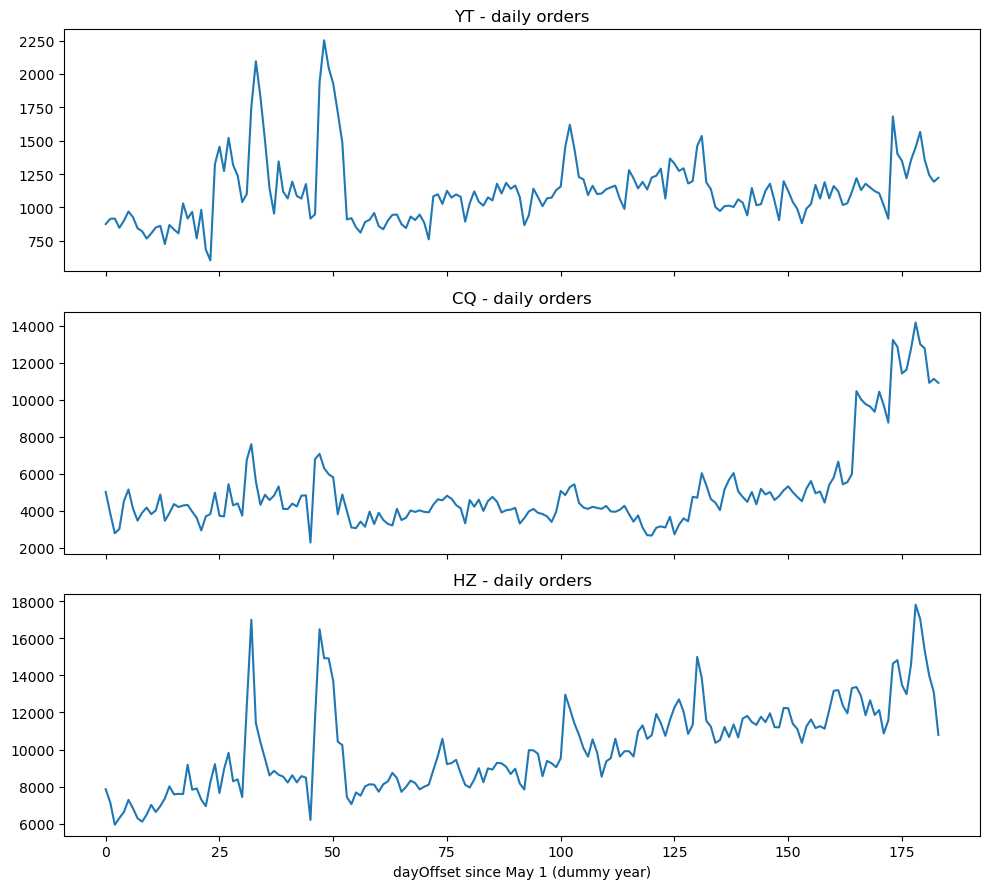

In [7]:
fig, axes = plt.subplots(len(CITY_CODES), 1, figsize=(10, 3 * len(CITY_CODES)), sharex=True)
axList = np.atleast_1d(axes)
for ax, cityCode in zip(axList, CITY_CODES):
    ax.plot(dailyByCity[cityCode].index, dailyByCity[cityCode].values)
    ax.set_title(f"{cityCode.upper()} - daily orders")
axList[-1].set_xlabel("dayOffset since May 1 (dummy year)")
fig.tight_layout()
fig.savefig(FIG_DIR / "daily_orders.png", dpi=150)


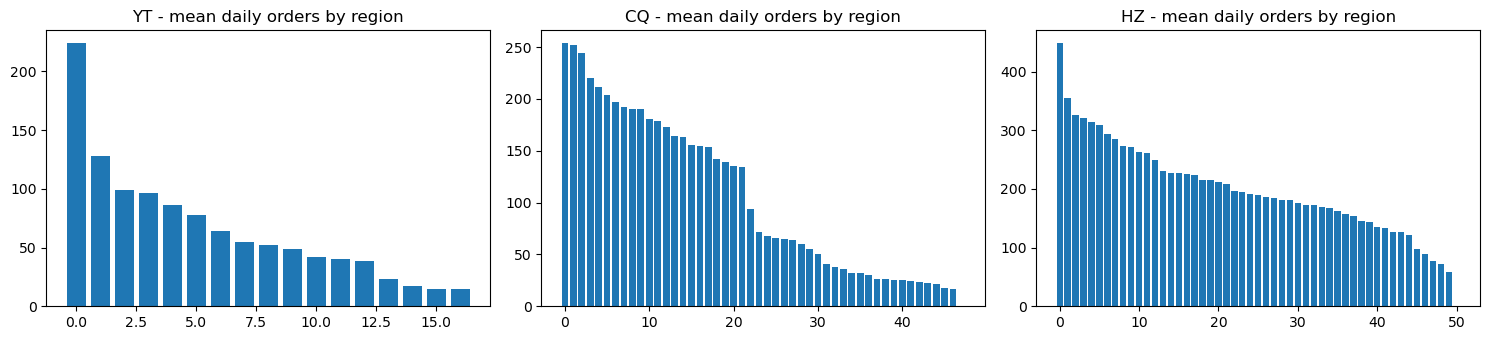

In [8]:
fig2, axes2 = plt.subplots(1, len(CITY_CODES), figsize=(5 * len(CITY_CODES), 3.5))
for ax, cityCode in zip(np.atleast_1d(axes2), CITY_CODES):
    ordered = regionMeanByCity[cityCode].sort_values(ascending=False)
    ax.bar(range(len(ordered)), ordered.values)
    ax.set_title(f"{cityCode.upper()} - mean daily orders by region")
fig2.tight_layout()
fig2.savefig(FIG_DIR / "region_mean_orders.png", dpi=150)
